# Lab 6

### My assigned state: Connecticut

In [4]:
# Secret manager function

import boto3
from botocore.exceptions import ClientError
import json

def get_secret(secret_name):
    region_name = "us-east-1"

    # Create a Secrets Manager client
    session = boto3.session.Session()
    client = session.client(
        service_name='secretsmanager',
        region_name=region_name
    )

    try:
        get_secret_value_response = client.get_secret_value(
            SecretId=secret_name
        )
    except ClientError as e:
        raise e

    secret = get_secret_value_response['SecretString']
    
    return json.loads(secret)

In [5]:
# Connecting to database

import psycopg2

conn = psycopg2.connect(host=get_secret('postgresql')['host'],
                      user=get_secret('postgresql')['username'],
                      password = get_secret('postgresql')['password'],
                      dbname=get_secret('postgresql')['engine'])

cur = conn.cursor()

# Question 1
Write an SQL query to retrieve the yearly population for your state.

• Decide how to calculate year-over-year growth rate:

o Option A: compute growth rate in SQL (preferred for Don’t Move the
Data Principle)

o Option B: compute growth rate in Python after loading population data

o You may need AI assistance to write the join query correctly.

• Use Jupyter AI to help write the Python code that loads the results and creates a
line chart with the growth rate.

• Chart must include the state name in the title.

• Provide a markdown explanation.


In [17]:
# fips = '09'
# Population year over year
sql = """
SELECT
  year,
  pop,
  LAG(pop) OVER (ORDER BY year) AS prev_pop,
  ROUND(
    ( (pop - LAG(pop) OVER (ORDER BY year))
      / NULLIF(LAG(pop) OVER (ORDER BY year), 0)::numeric
    ) * 100,
    2
  ) AS yoy_growth_pct
FROM population
WHERE fips = '09'
ORDER BY year;
"""

In [21]:
import pandas as pd

df = pd.read_sql(sql, con=conn)
df.head() #show the top 5 rows

,year,pop,prev_pop,yoy_growth_pct
0,2005,3394751,NaN,NaN
1,2006,3504809,3394751.0,3.24
2,2007,3502309,3504809.0,-0.07
3,2008,3501252,3502309.0,-0.03
4,2009,3518288,3501252.0,0.49


# Using AI assistance to create charts

In [7]:
! pip install jupyter-ai-magics[all] -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
safety-schemas 0.0.14 requires pydantic<2.10.0,>=2.6.0, but you have pydantic 2.11.9 which is incompatible.
sparkmagic 0.21.0 requires pandas<2.0.0,>=0.17.1, but you have pandas 2.2.3 which is incompatible.


In [8]:
import warnings
warnings.simplefilter('ignore')

In [9]:
import os
os.environ["OPENAI_API_KEY"] = get_secret('openai')['api_key']

In [10]:
%load_ext jupyter_ai_magics

In [31]:
%%ai gpt4
Using the dataframe from up above a few rows, create a line chart of yoy population growth over time. The df column is called yoy_growth_pct. Make sure to include the state name (Connecticut) in the title.

To create a line chart plotting Year-Over-Year (YOY) population growth percentage over time for the state of Connecticut, you can use matplotlib library. If the dataframe is denoted as `df` and contains columns "year" and "yoy_growth_pct", see the Python code here:

```python
# Import the necessary library
import matplotlib.pyplot as plt

# Ensure 'year' is of datetime type
df['year'] = pd.to_datetime(df['year'], format='%Y')

# Sort DataFrame by 'year'
df = df.sort_values('year')

# Plot YOY population growth rate over time
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['yoy_growth_pct'], label='YOY Population Growth')

plt.xlabel('Year')
plt.ylabel('YOY Population Growth (%)')
plt.title('YOY Population Growth Over Time in Connecticut')
plt.legend()
plt.grid(True)
plt.show()
```

This code will output a line chart, where the x-axis signifies the 'year' column, and the 'yoy_growth_pct' column (reflecting the growth in population) is depicted on the y-axis. 

This code assumes 'yoy_growth_pct' stores the growth percentage as a numeric value and that your "year" column is a recognized date format. Please adjust the date format in the `pd.to_datetime()` function based on your dataframe. Lastly, replace the column names in the code as per your dataframe if they differ. Also, adjust the figure size and labels as needed based on your specific requirements.

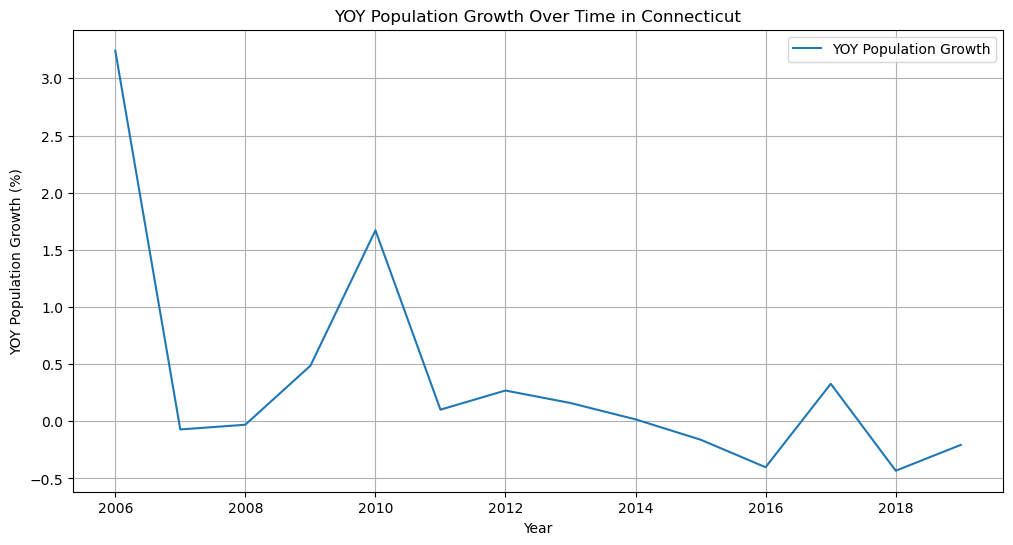

In [32]:
# Import the necessary library
import matplotlib.pyplot as plt

# Ensure 'year' is of datetime type
df['year'] = pd.to_datetime(df['year'], format='%Y')

# Sort DataFrame by 'year'
df = df.sort_values('year')

# Plot YOY population growth rate over time
plt.figure(figsize=(12, 6))
plt.plot(df['year'], df['yoy_growth_pct'], label='YOY Population Growth')

plt.xlabel('Year')
plt.ylabel('YOY Population Growth (%)')
plt.title('YOY Population Growth Over Time in Connecticut')
plt.legend()
plt.grid(True)
plt.show()